In [1]:
n_jobs= 60
#libraries
import pandas as pd
import numpy as np
import os
import sys
from glob import glob
import joblib
import warnings
from datetime import date, datetime
import copy

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from scipy.stats import pearsonr
import scipy.stats as st

from sklearn.utils._testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning

import pickle

from sklearn.compose import TransformedTargetRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import PowerTransformer

from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path='/scratch2/alinat/project/PD-EEG-ANON_eegOnly/MLtables180'

In [3]:
import pickle

fnm = '/MLout/MLlvl1_bestPerf_r2_among6alg_STDonly_BT.pkl'

with open(path + fnm, 'rb') as file:
    dct_best_perf_alg_loaded = pickle.load(file)


In [4]:
dct_r2 = {}
for file in sorted(glob(path+'/MLout/performance_boot_ZnoLG_lvl1_lvl2_lvlFlat_tabs/MLlvl1_*_r2_performance_bootstr.csv')):
    t_ = pd.read_csv(file, index_col=0)
    trg, mln = file.split('/')[-1].replace('MLlvl1_','').replace('_r2_performance_bootstr.csv', '').split('__')
    dct_r2[mln] = {}
    dct_r2[mln][trg] = {}
    dct_r2[mln][trg]['r2'] = t_

In [5]:
dct_cor = {}
for file in sorted(glob(path+'/MLout/performance_boot_ZnoLG_lvl1_lvl2_lvlFlat_tabs/MLlvl1_*_cor_performance_bootstr.csv')):
    t_ = pd.read_csv(file, index_col=0)
    trg, mln = file.split('/')[-1].replace('MLlvl1_','').replace('_cor_performance_bootstr.csv', '').split('__')
    dct_cor[mln] = {}
    dct_cor[mln][trg] = {}
    dct_cor[mln][trg]['cor'] = t_

In [6]:
bbb = pd.Series(dct_best_perf_alg_loaded['global_z_no_language'])

In [7]:
import scipy.stats as stats

aec = bbb[[i for i in bbb.index if "STD" in i and 'aec' in i]].sort_index().values
dwpli = bbb[[i for i in bbb.index if "STD" in i and 'dwpli' in i]].sort_index().values

t_stat, p_val = stats.ttest_ind(aec, dwpli, equal_var=False)
print(f"t = {t_stat:.3f}, p = {p_val:.3f}")


diff = aec - dwpli
cohens_d = diff.mean() / diff.std(ddof=1)
print(f"Cohen's d = {cohens_d:.3f}")



t = 0.360, p = 0.728
Cohen's d = 0.394


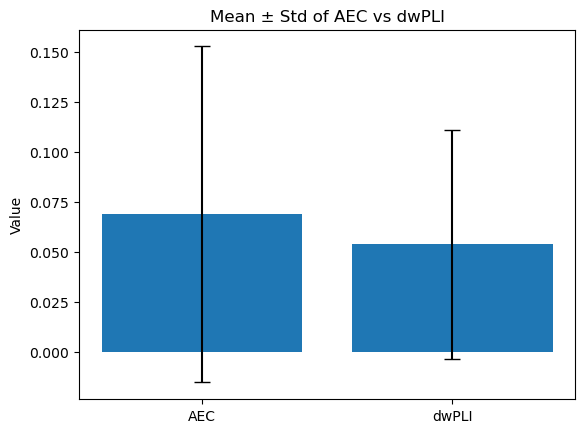

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Get your arrays
aec = bbb[[i for i in bbb.index if "STD" in i and 'aec' in i]].sort_index().values
dwpli = bbb[[i for i in bbb.index if "STD" in i and 'dwpli' in i]].sort_index().values

# Compute means and stds
means = [aec.mean(), dwpli.mean()]
stds = [aec.std(ddof=1), dwpli.std(ddof=1)]

# Labels
labels = ["AEC", "dwPLI"]

# Plot
plt.bar(labels, means, yerr=stds, capsize=6)
plt.ylabel("Value")
plt.title("Mean ± Std of AEC vs dwPLI")
plt.show()


In [9]:
print(means)

[np.float64(0.06868066582583361), np.float64(0.05373962025643405)]


In [10]:
best_eeg_mod = bbb[[i for i in bbb.index if 'aec' in i or 'dwpli' in i]]
print(best_eeg_mod)

STD_diagonal_aec_theta___rf        0.169537
STD_diagonal_aec_alpha___krr       0.151612
IND_diagonal_aec_theta___xgb       0.138397
STD_diagonal_dwpli_theta___rf      0.138149
IND_diagonal_aec_alpha___enet      0.122712
IND_diagonal_aec_beta___pls        0.107127
STD_diagonal_aec_beta___pls        0.101147
STD_diagonal_dwpli_alpha___xgb     0.093196
IND_diagonal_dwpli_theta___xgb     0.092380
IND_diagonal_dwpli_alpha___enet    0.074409
STD_diagonal_dwpli_delta___xgb     0.058972
STD_diagonal_dwpli_beta___rf       0.046967
STD_diagonal_aec_delta___rf        0.029995
IND_diagonal_aec_delta___enet      0.027247
IND_diagonal_dwpli_gamma1___xgb    0.016473
IND_diagonal_dwpli_beta___xgb      0.011139
IND_diagonal_dwpli_gamma2___rf     0.005169
STD_diagonal_dwpli_gamma1___rf     0.001411
IND_diagonal_aec_gamma2___enet    -0.006058
STD_diagonal_aec_gamma1___xgb     -0.015778
STD_diagonal_dwpli_gamma2___xgb   -0.016259
STD_diagonal_aec_gamma2___enet    -0.024429
IND_diagonal_aec_gamma1___rf    

In [11]:
df_bt_best_r2 = pd.DataFrame()
df_bt_best_cor = pd.DataFrame()
for mod in best_eeg_mod.index:
    mlalg = mod.split('___')[-1]
    tmod = mod.split('___')[0]

    df_bt_best_r2 = pd.concat([df_bt_best_r2, dct_r2[mlalg]['global_z_no_language']['r2'][tmod]], axis=1)
    df_bt_best_cor = pd.concat([df_bt_best_cor, dct_cor[mlalg]['global_z_no_language']['cor'][tmod]], axis=1)


In [12]:
df = df_bt_best_r2


df.columns = [i.replace('_diagonal_', '_') for i in df.columns]
df.columns = [i.replace('aec_ind', 'AEC_IND').replace('aec_std', 'AEC_STD').replace('dwpli_ind', 'dwPLI_IND').replace('dwpli_std', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in df.columns]
df.columns = [i.replace('IND_aec', 'AEC_IND').replace('STD_aec', 'AEC_STD').replace('IND_dwpli', 'dwPLI_IND').replace('STD_dwpli', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in df.columns]

df1_ = df.loc[:,[i  for i in df.columns if 'STD' in i]]
df2_ = df.loc[:,[i  for i in df.columns if 'IND' in i]]

df1_.columns = [i.replace('_STD_', '_') for i in df1_.columns]
df2_.columns = [i.replace('_IND_', '_') for i in df2_.columns]

df1_ = df1_.reindex(columns=df1_.mean().sort_values().index)
df2_ = df2_.reindex(columns = df1_.columns)

ind_cor_ord = copy.deepcopy(df1_.columns)

df_r2_diff = pd.DataFrame()
for col in df1_.columns:
    df_r2_diff[col+'__STD-vs-IND'] = df1_[col] - df2_[col]

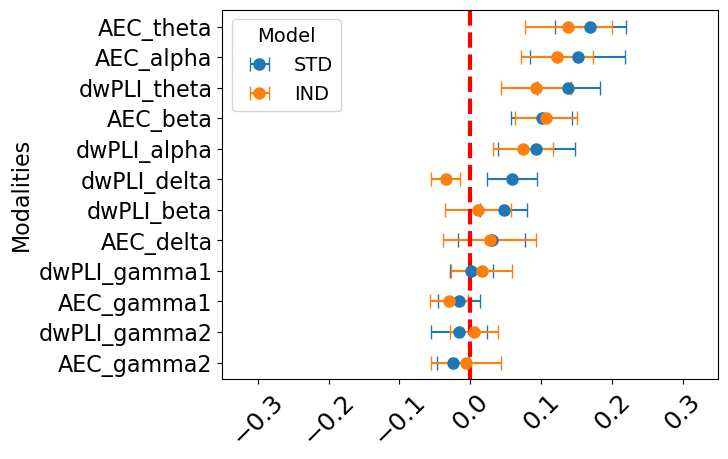

In [13]:
plt.errorbar(
    x=df1_.mean().values,
    y=df1_.mean().index,
    xerr=df1_.std().values,
    fmt='o',           # 'o' = dot marker
    capsize=5,         # little horizontal lines at error bar ends
    markersize=8,
    color=plt.cm.tab10.colors[0],
    label='STD'
)

plt.errorbar(
    x=df2_.mean().values,
    y=df2_.mean().index,
    xerr=df2_.std().values,
    fmt='o',           # 'o' = dot marker
    capsize=5,         # little horizontal lines at error bar ends
    markersize=8,
    color=plt.cm.tab10.colors[1],
    label='IND'
)


#plt.xlabel(fontsize=18)
plt.xticks(rotation=45, fontsize=18)
plt.ylabel('Modalities', fontsize=16)
plt.yticks(fontsize=16)
#plt.title(f'Performance, {target}, {ttl}', fontsize=24)
plt.legend(title='Model', loc='upper left', fontsize=14, title_fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=3)
plt.xlim([-0.35, 0.35])

plt.show()

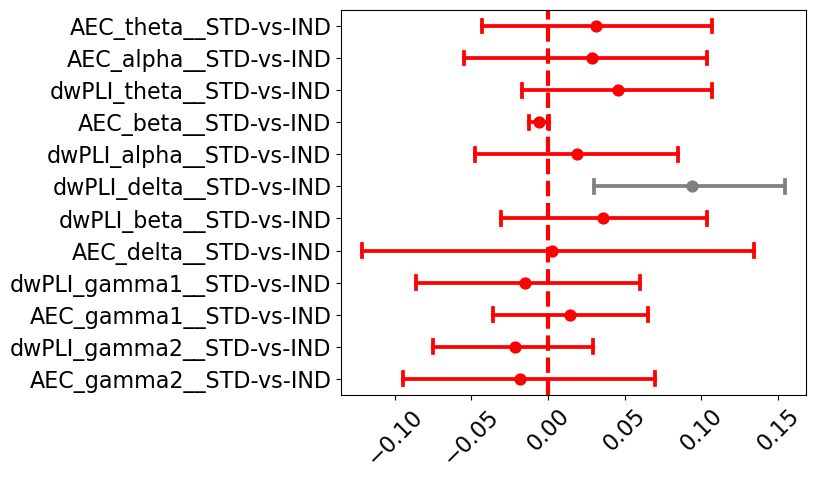

In [14]:
data = df_r2_diff.iloc[:, ::-1]

#make pallette
my_pal = []
for col in data.columns:
    ci1 = np.percentile(data[col], [2.5, 97.5])[0]
    if ci1 <0:
        my_pal += ['red']
    else:
        my_pal += ['gray']

#plotting func
fig = plt.figure(figsize=(6, 5))

def my_func(vec):
    ci = np.percentile(vec, [2.5, 97.5])
    return ci

sns.pointplot(data = data, orient='h',  errorbar=my_func, capsize=.4,  palette=my_pal)

plt.axvline(0, color='r', linestyle='dashed', linewidth=3)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)

#plt.title('All Models:\n'+targ_mod_ttl, fontsize=16)

plt.show()

In [15]:
df = df_bt_best_cor


df.columns = [i.replace('_diagonal_', '_') for i in df.columns]
df.columns = [i.replace('aec_ind', 'AEC_IND').replace('aec_std', 'AEC_STD').replace('dwpli_ind', 'dwPLI_IND').replace('dwpli_std', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in df.columns]
df.columns = [i.replace('IND_aec', 'AEC_IND').replace('STD_aec', 'AEC_STD').replace('IND_dwpli', 'dwPLI_IND').replace('STD_dwpli', 'dwPLI_STD').replace('str', 'STR').replace('ANAT', 'STR')  for i in df.columns]

df1_ = df.loc[:,[i  for i in df.columns if 'STD' in i]]
df2_ = df.loc[:,[i  for i in df.columns if 'IND' in i]]

df1_.columns = [i.replace('_STD_', '_') for i in df1_.columns]
df2_.columns = [i.replace('_IND_', '_') for i in df2_.columns]

df1_ = df1_.reindex(columns = ind_cor_ord) #df1_.mean().sort_values().index)
df2_ = df2_.reindex(columns = ind_cor_ord) #df1_.columns)



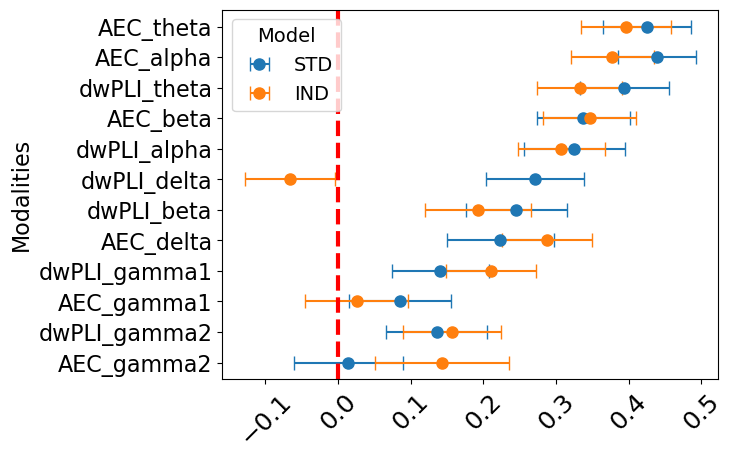

In [16]:
plt.errorbar(
    x=df1_.mean().values,
    y=df1_.mean().index,
    xerr=df1_.std().values,
    fmt='o',           # 'o' = dot marker
    capsize=5,         # little horizontal lines at error bar ends
    markersize=8,
    color=plt.cm.tab10.colors[0],
    label='STD'
)

plt.errorbar(
    x=df2_.mean().values,
    y=df2_.mean().index,
    xerr=df2_.std().values,
    fmt='o',           # 'o' = dot marker
    capsize=5,         # little horizontal lines at error bar ends
    markersize=8,
    color=plt.cm.tab10.colors[1],
    label='IND'
)


#plt.xlabel(fontsize=18)
plt.xticks(rotation=45, fontsize=18)
plt.ylabel('Modalities', fontsize=16)
plt.yticks(fontsize=16)
#plt.title(f'Performance, {target}, {ttl}', fontsize=24)
plt.legend(title='Model', loc='upper left', fontsize=14, title_fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=3)
#plt.xlim([-0.35, 0.35])

plt.show()